# Agent

# 기본 import

In [1]:
import os
from langchain_openai.chat_models.base import ChatOpenAI
from langchain.messages import HumanMessage, SystemMessage, AIMessage
from pprint import pprint

from dotenv import load_dotenv
load_dotenv()

True

# LLM 이 하지 못하는 것

In [2]:
llm = ChatOpenAI(temperature=0.1)

In [3]:
prompt = "Cost of $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12"

In [4]:
llm.invoke(prompt)

AIMessage(content='= $4923.38', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 59, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DfOOMzCy9U2WcEKZlAAguhzvKj6dS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2636-bb09-79e0-8299-6658d2440a54-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 6, 'total_tokens': 65, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
# $4923.38  라는데 맞을까?

# $355.39 + $924.87 + $721.2 + $1940.29 + $573.63 + $65.72 + $35.00 + $552.00 + $76.16 + $29.12

# 결과는 5273.38 가 나와야 한다!  --> LLM 이 틀렸다!!💥


# LLM 이 숫자를 자연어 파싱하면서... 소수점(.) 을 문장 구분 기호로 오해할수도 있다.

# 355.39 + 924.87  같은 표현을
#   355.  + 39  + 924. + 87  <- 문장단위로 잘라 해석할수도 있다.

# 'Cost of $'  .. 같은 자연어도 제거되어야 할것이고
# '$' 통화기호도 파싱을 방행할수 있다.




In [5]:
llm = ChatOpenAI(temperature=0.1, model='gpt-4o-mini')
llm.invoke(prompt)

AIMessage(content='To find the total cost, we can add all the amounts together:\n\n\\[\n355.39 + 924.87 + 721.20 + 1940.29 + 573.63 + 65.72 + 35.00 + 552.00 + 76.16 + 29.12\n\\]\n\nCalculating step by step:\n\n1. \\( 355.39 + 924.87 = 1280.26 \\)\n2. \\( 1280.26 + 721.20 = 2001.46 \\)\n3. \\( 2001.46 + 1940.29 = 3941.75 \\)\n4. \\( 3941.75 + 573.63 = 4515.38 \\)\n5. \\( 4515.38 + 65.72 = 4581.10 \\)\n6. \\( 4581.10 + 35.00 = 4616.10 \\)\n7. \\( 4616.10 + 552.00 = 5168.10 \\)\n8. \\( 5168.10 + 76.16 = 5244.26 \\)\n9. \\( 5244.26 + 29.12 = 5273.38 \\)\n\nThus, the total cost is **$5273.38**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 277, 'prompt_tokens': 59, 'total_tokens': 336, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-

In [ ]:
# ★LLM 은 산술연산을 할수 없다!!
# LLM은 '산술연산'을 수행하지 않습니다.  이런 계산은 AI보다 '계산기'가 더 잘한다!
# LLM 은 text 를 생성해내는 겁니다. 문장 시퀀스의 다음 token 이 무엇인지 통계적으로 추측하는 겁니다.

# 이러한 LLM 의 오류를 잡기위해선 agent 를 제공해주어야 한다.
# 그리고 agent 를 위한 tool(들) 을 만들고, agent 가 tool 을 선택해서 실행하는 것이다.


In [ ]:
# 에이전트는 언어 모델과 도구를 결합하여 작업에 대해 추론하고, 사용할 도구를 결정하고, 
# 반복적으로 해결책을 찾아낼 수 있는 시스템

# create_agent()

Creates an agent graph that calls tools in a loop until a stopping condition is met.


- `create_agent` 실제 운영 환경에서 사용 가능한 에이전트 구현을 제공합니다.
- Creates an agent graph that calls tools in a loop until a stopping condition is met.

- `create_agent` 는 LangGraph를 사용하여 그래프 기반 에이전트 런타임을 구축합니다 . 
- 그래프는 에이전트가 정보를 처리하는 방식을 정의하는 노드(단계)와 엣지(연결)로 구성됩니다. 
- 에이전트는 이 그래프를 따라 이동하며 모델 노드(모델을 호출), 도구 노드(도구를 실행), 미들웨어와 같은 노드를 실행합니다.

- https://reference.langchain.com/python/langchain/agents/?h=create_agent#langchain.agents.create_agent

- https://docs.langchain.com/oss/python/langchain/agents




```python
create_agent(
    model: str | BaseChatModel,
    tools: Sequence[BaseTool | Callable[..., Any] | dict[str, Any]] | None = None,  # A list of tools, dict, or Callable.
    *,
    system_prompt: str | SystemMessage | None = None,
    middleware: Sequence[AgentMiddleware[StateT_co, ContextT]] = (),
    response_format: ResponseFormat[ResponseT]
    | type[ResponseT]
    | dict[str, Any]
    | None = None,
    state_schema: type[AgentState[ResponseT]] | None = None,
    context_schema: type[ContextT] | None = None,
    checkpointer: Checkpointer | None = None,
    store: BaseStore | None = None,
    interrupt_before: list[str] | None = None,
    interrupt_after: list[str] | None = None,
    debug: bool = False,
    name: str | None = None,
    cache: BaseCache[Any] | None = None,
) -> CompiledStateGraph[
    AgentState[ResponseT], ContextT, _InputAgentState, _OutputAgentState[ResponseT]
]
```

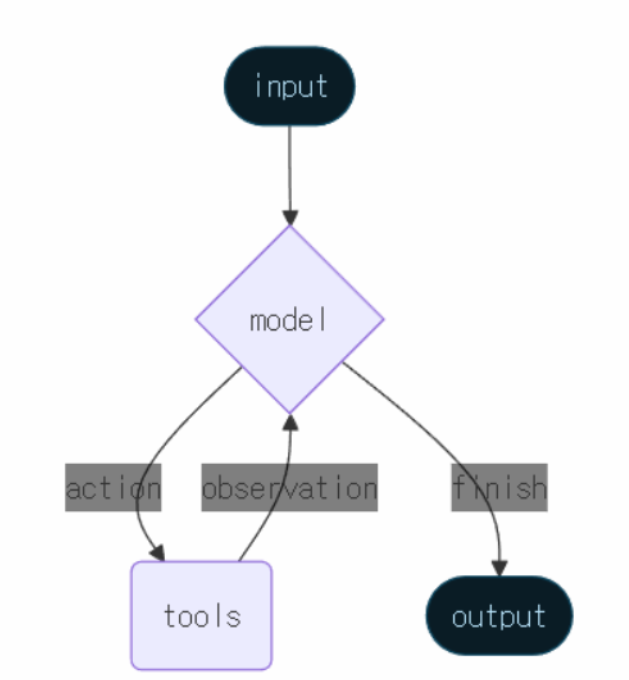

In [6]:
from langchain.agents import create_agent

# tool

In [9]:
# agent 에 전달할 tool 준비  

# 기본적으로 tool 은 함수다.
def plus(a, b):
    return a + b

# 이 함수를 우리 agent 가 실제로 사용할수 있는 tool 로 변환해서 전달해주어야 한다
#   여기선 우린 StructuredTool 를 사용해보겠다.    

In [7]:
from langchain_core.tools.structured import StructuredTool

# StructuredTool 는 매개변수를 여러개 받을수 있는 tool 

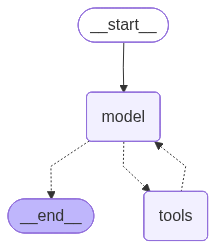

In [10]:
agent = create_agent(
    model = ChatOpenAI(
        temperature=0.0,
        model='gpt-4o',
    ),

    tools=[  # tool(들) 전달
        StructuredTool.from_function(
            func=plus,  # 함수 -> tool 변환
            name="SumCalculator",  # tool 이름 지정 (✅공백불가✅)
            description="Use this to perform sum of two numbers. This tool take two arguments, both  should be numbers.",
        ),
    ],
    debug=True,  # 디버깅모드 출력
)

agent

# agent 호출
- agent 도 Runnable 객체  .invoke() 있다.  chain 내에서도 사용 가능.

In [11]:
result = agent.invoke({
    "messages": [
        {"role": "user",
         "content": """
            Calculate the following numbers mathematically.
            Do not interpret them as sentences; treat all values as numbers and calculate the sum of all numbers.

            355.39 + 924.87 + 721.20 + 1940.29 + 573.63 + 65.72 + 35.00 + 552.00 + 76.16 + 29.12         
         """,
        }
    ],
})

[values] {'messages': [HumanMessage(content='\n            Calculate the following numbers mathematically.\n            Do not interpret them as sentences; treat all values as numbers and calculate the sum of all numbers.\n\n            355.39 + 924.87 + 721.20 + 1940.29 + 573.63 + 65.72 + 35.00 + 552.00 + 76.16 + 29.12         \n         ', additional_kwargs={}, response_metadata={}, id='e1c26b3f-ed45-4885-9765-ef55d4bbfaba')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 145, 'total_tokens': 268, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfOnWDiQtr8g8I1v0vTMBXxZ9znzw', 'service_tier'

In [12]:
result

{'messages': [HumanMessage(content='\n            Calculate the following numbers mathematically.\n            Do not interpret them as sentences; treat all values as numbers and calculate the sum of all numbers.\n\n            355.39 + 924.87 + 721.20 + 1940.29 + 573.63 + 65.72 + 35.00 + 552.00 + 76.16 + 29.12         \n         ', additional_kwargs={}, response_metadata={}, id='e1c26b3f-ed45-4885-9765-ef55d4bbfaba'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 145, 'total_tokens': 268, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfOnWDiQtr8g8I1v0vTMBXxZ9znzw', 'service_tier': 'default', 'finish_reason': 'tool_calls'

In [13]:
result['messages'][-1].content  # Agent 의 최종 답변.

'The sum of the numbers is 5168.1.'

In [14]:
result.keys()

dict_keys(['messages'])

In [15]:
len(result['messages'])   # list   <- 14개의 Message

14

In [16]:
result['messages'][0]  # HumanMessage

HumanMessage(content='\n            Calculate the following numbers mathematically.\n            Do not interpret them as sentences; treat all values as numbers and calculate the sum of all numbers.\n\n            355.39 + 924.87 + 721.20 + 1940.29 + 573.63 + 65.72 + 35.00 + 552.00 + 76.16 + 29.12         \n         ', additional_kwargs={}, response_metadata={}, id='e1c26b3f-ed45-4885-9765-ef55d4bbfaba')

In [17]:
result['messages'][1]  # AIMessage

# content=''  없다!
# tool_calls=[]  주목!  tool 호출 응답

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 145, 'total_tokens': 268, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfOnWDiQtr8g8I1v0vTMBXxZ9znzw', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e264e-89c0-7920-ae58-791f3116664f-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 355.39, 'b': 924.87}, 'id': 'call_eXie1lBVj9ddJN8Bp4LsQcJA', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 721.2, 'b': 1940.29}, 'id': 'call_JLVU0PlwvoZ8EpR59OhZUQY3', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 573.63, 'b': 65.72}, 'id': 'call_yrHgEkomZwT2KXclf4GD

In [18]:
# 355.39 + 924.87 + 721.20 + 1940.29 + 573.63 + 65.72 + 35.00 + 552.00 + 76.16 + 29.12

result['messages'][1].tool_calls


[{'name': 'SumCalculator',
  'args': {'a': 355.39, 'b': 924.87},
  'id': 'call_eXie1lBVj9ddJN8Bp4LsQcJA',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 721.2, 'b': 1940.29},
  'id': 'call_JLVU0PlwvoZ8EpR59OhZUQY3',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 573.63, 'b': 65.72},
  'id': 'call_yrHgEkomZwT2KXclf4GD52Bz',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 35, 'b': 552},
  'id': 'call_weEeibgcrZc3WEKCBiuuS28t',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 76.16, 'b': 29.12},
  'id': 'call_shhKepERaOrCYPoNBd5JOHRx',
  'type': 'tool_call'}]

In [ ]:
# 'finish_reason': 'tool_calls'  <- 아직 작업이 안끝남.   tool_calls 해야 함!

# 이후 Agent 에서 위 5번의 tool 호출이 이루어진다.
# 그 결과가 다음 5번의 ToolMessage 에 나타날거다.

In [19]:
result['messages'][2:7]  # ToolMessage 들

# content=  우리의 plus() 함수가 호출되고 리턴함 값들

[ToolMessage(content='1280.26', name='SumCalculator', id='6ec34d28-3a7d-4311-b56f-a36107625cc0', tool_call_id='call_eXie1lBVj9ddJN8Bp4LsQcJA'),
 ToolMessage(content='2661.49', name='SumCalculator', id='42ae375f-35b7-482b-af1c-fd6f20fd492f', tool_call_id='call_JLVU0PlwvoZ8EpR59OhZUQY3'),
 ToolMessage(content='639.35', name='SumCalculator', id='0e26aac3-270f-44b5-b040-1afb5fab0808', tool_call_id='call_yrHgEkomZwT2KXclf4GD52Bz'),
 ToolMessage(content='587', name='SumCalculator', id='72057220-aa6b-436e-a7d4-9f415b897192', tool_call_id='call_weEeibgcrZc3WEKCBiuuS28t'),
 ToolMessage(content='105.28', name='SumCalculator', id='8e37f107-923f-4285-b551-c1ea8f6343c8', tool_call_id='call_shhKepERaOrCYPoNBd5JOHRx')]

In [20]:
result['messages'][7]  # 다시 AIMessage

# 아직 task 가 끝나지 않았다.  <- 'finish_reason': 'tool_calls'
# Agent 는 목표를 이룰때까지 계속 진행.

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 303, 'total_tokens': 383, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfOnYdSaWW7BBBGvecg7xRABCCkx9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e264e-94f0-7b82-a586-e2c4c5bb379c-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 1280.26, 'b': 2661.49}, 'id': 'call_U2YkyHpW3mSfhubzXzO3Z0wt', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 639.35, 'b': 587}, 'id': 'call_5pj83aadVIzHvGycg4D3HvuS', 'type': 'tool_call'}, {'name': 'SumCalculator', 'args': {'a': 105.28, 'b': 0}, 'id': 'call_cgiNZKRiwK5yD5cDYQUYBEgn',

In [21]:
result['messages'][7].tool_calls

# [ToolMessage(content='1280.26', name='SumCalculator', id='6ec34d28-3a7d-4311-b56f-a36107625cc0', tool_call_id='call_eXie1lBVj9ddJN8Bp4LsQcJA'),
#  ToolMessage(content='2661.49', name='SumCalculator', id='42ae375f-35b7-482b-af1c-fd6f20fd492f', tool_call_id='call_JLVU0PlwvoZ8EpR59OhZUQY3'),
#  ToolMessage(content='639.35', name='SumCalculator', id='0e26aac3-270f-44b5-b040-1afb5fab0808', tool_call_id='call_yrHgEkomZwT2KXclf4GD52Bz'),
#  ToolMessage(content='587', name='SumCalculator', id='72057220-aa6b-436e-a7d4-9f415b897192', tool_call_id='call_weEeibgcrZc3WEKCBiuuS28t'),
#  ToolMessage(content='105.28', name='SumCalculator', id='8e37f107-923f-4285-b551-c1ea8f6343c8', tool_call_id='call_shhKepERaOrCYPoNBd5JOHRx')]

[{'name': 'SumCalculator',
  'args': {'a': 1280.26, 'b': 2661.49},
  'id': 'call_U2YkyHpW3mSfhubzXzO3Z0wt',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 639.35, 'b': 587},
  'id': 'call_5pj83aadVIzHvGycg4D3HvuS',
  'type': 'tool_call'},
 {'name': 'SumCalculator',
  'args': {'a': 105.28, 'b': 0},
  'id': 'call_cgiNZKRiwK5yD5cDYQUYBEgn',
  'type': 'tool_call'}]

In [22]:
result['messages'][7].response_metadata['finish_reason']  # 이 값이 "stop" 이어야 Agent 가 종료됨.

'tool_calls'

In [23]:
# 그 다음 3개는 ToolMessage 일 것이다
result['messages'][8:11]

[ToolMessage(content='3941.75', name='SumCalculator', id='aa8117e4-5c6a-4853-b203-43827f8dbe46', tool_call_id='call_U2YkyHpW3mSfhubzXzO3Z0wt'),
 ToolMessage(content='1226.35', name='SumCalculator', id='437170e4-f868-4fab-93f1-a45a71f04889', tool_call_id='call_5pj83aadVIzHvGycg4D3HvuS'),
 ToolMessage(content='105.28', name='SumCalculator', id='695ad845-0138-486a-80c8-28b9dbf0fd23', tool_call_id='call_cgiNZKRiwK5yD5cDYQUYBEgn')]

In [24]:
# 위 tool 호출 결과를 받은 AIMessage
result['messages'][11]

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 410, 'total_tokens': 434, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfOnaTq08mU5AwDyulJtrTwY8ciqC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e264e-99e3-7e43-85fb-ce7d14c9b583-0', tool_calls=[{'name': 'SumCalculator', 'args': {'a': 3941.75, 'b': 1226.35}, 'id': 'call_prGYqKUsywukojDOd7FDP4Ad', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 410, 'output_tokens': 24, 'total_tokens': 434, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [25]:
result['messages'][11].tool_calls

[{'name': 'SumCalculator',
  'args': {'a': 3941.75, 'b': 1226.35},
  'id': 'call_prGYqKUsywukojDOd7FDP4Ad',
  'type': 'tool_call'}]

In [26]:
result['messages'][12]

ToolMessage(content='5168.1', name='SumCalculator', id='d8e0b675-a24b-49bf-a875-5a4fd677bee6', tool_call_id='call_prGYqKUsywukojDOd7FDP4Ad')

In [27]:
result['messages'][13] # AiMessage

# content="...."
# 'finish_reason': 'stop'  <- Agent 종료!

AIMessage(content='The sum of the numbers is 5168.1.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 446, 'total_tokens': 459, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfOnbURcDEJso64Xvsn85DU90vIZu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e264e-a05f-7b83-86bf-499adfb1d0e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 446, 'output_tokens': 13, 'total_tokens': 459, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [29]:
result['messages'][-1].response_metadata['finish_reason']

'stop'

# LangSmith 에서 확인